In [1]:
import numpy as np
import scipy as sc
import matplotlib.pyplot as plt
import pandas as pd
import mendeleev as mdl
from mendeleev import C, O, Al, Si, Ca, Cr, Mn, Fe, Co, Ni, Cu, Au, Sn, S, Zn

from matplotlib import rc
# rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
## for Palatino and other serif fonts use:
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times"],
    "text.usetex": True,
    "font.size": 8,
    "pgf.rcfonts": False
})

In [22]:
n = 2
E = np.exp(-1)
print('n, E_n')
while n != 21:
    E_n = 1 - n*E #E_n
    print(n,E_n)
    E = E_n # E_n -> E_n-1
    n += 1

n, E_n
2 0.26424111765711533
3 0.207276647028654
4 0.17089341188538398
5 0.14553294057308008
6 0.1268023565615195
7 0.11238350406936348
8 0.10093196744509214
9 0.09161229299417073
10 0.0838770700582927
11 0.07735222935878028
12 0.07177324769463667
13 0.06694777996972334
14 0.06273108042387321
15 0.059033793641901866
16 0.05545930172957014
17 0.05719187059730757
18 -0.029453670751536265
19 1.559619744279189
20 -30.19239488558378


In [7]:
dNdt = np.array([10**(-12)/(1.602*10**(-19)),10**(-11)/(1.602*10**(-19)),10**(-10)/(1.602*10**(-19)),10**(-9)/(1.602*10**(-19)),10**(-8)/(1.602*10**(-19)),10**(-7)/(1.602*10**(-19)),10**(-6)/(1.602*10**(-19)),10**(-5)/(1.602*10**(-19)),10**(-4)/(1.602*10**(-19)),10**(-3)/(1.602*10**(-19))]) #particle rate per second for protons


# Data from Paul & Sacher

b = 10**(-24) #cm²
data_6_C = [[0.5,0.7,1,1.6,2,3],[9.547*10**5,9.626*10**5,9.008*10**5,7.521*10**5,6.709*10**5,5.268*10**5],'Carbon-6',1,6]
data_8_O = [[0.5,0.7,1,1.6,2,3,4,5,6],[1.952*10**5,2.348*10**5,2.568*10**5,2.521*10**5,2.389*10**5,2.040*10**5,1.758*10**5,1.542*10**5,1.373*10**5],'Oxygen-8',1,8]

data_13_Al = [[0.5,0.7,1,1.6,2,3,4,5,6,7,8,9,10],[0.6141,1.086,1.704,2.502,2.791,3.072,3.063,2.951,2.806,2.655,2.510,2.375,2.252],'Aluminum-13',10**4,13]
data_14_Si = [[0.5,0.7,1,1.6,2,3,4,5,6,7,8,9,10,11,12],[0.3190,0.6037,1.014,1.611,1.857,2.155,2.218,2.184,2.109,2.019,1.927,1.836,1.751,1.671,1.598],'Silicon-14',10**4,14]

data_20_Ca = [[0.5,0.7,1,1.6,2,3,4,5,6,7,8,9,10,11,12],[0.09707,0.2473,0.5757,1.382,1.908,2.979,4.141,4.407,4.550,4.611,4.618,4.587,4.533,4.462,4.295],'Calcium-20',10**3,20]

data_24_Cr = [[0.5,0.7,1,1.6,2,3,4,5,6,7,8,9,10,11,12,14],[0.01382,0.03981,0.1071,0.3158,0.4814,0.8923,1.238,1.504,1.703,1.847,1.949,2.019,2.064,2.091,2.104,2.099],'Chromium-24',10**3,24]
data_25_Mn = [[0.5,0.7,1,1.6,2,3,4,5,6,7,8,9,10,11,12,14],[0.0838,0.2611,0.7236,2.228,3.470,6.686,9.520,11.79,13.55,14.87,15.85,16.55,17.04,17.37,17.57,17.69],'Manganese-25',10**2,25]
data_26_Fe = [[0.5,0.7,1,1.6,2,3,4,5,6,7,8,9,10,11,12,14],[0.05720,0.1732,0.4932,1.582,2.515,5.030,7.346,9.272,10.81,12.00,12.91,13.60,14.10,14.46,14.71,14.94],'Iron-26',10**2,26]
data_27_Co = [[0.5,0.7,1,1.6,2,3,4,5,6,7,8,9,10,11,12,14],[0.03743,0.1160,0.3390,1.130,1.831,3.797,5.684,7.308,8.639,9.704,10.54,11.19,11.69,12.06,12.33,12.64],'Cobalt-27',10**2,27]
data_28_Ni = [[0.5,0.7,1,1.6,2,3,4,5,6,7,8,9,10,11,12,14],[0.02486,0.07877,0.2358,0.8142,1.344,2.884,4.421,5.785,6.934,7.877,8.637,9.242,9.717,10.09,10.37,10.72],'Nickel-28',10**2,28]


In [ ]:
dz = 0.001 #m
N_A = 6.022*10**(23)

N_f = dNdt*(C.density*N_A)/(C.atomic_weight)*dz*data_6_C[1][4]*b
print(N_f)


[4.61933592e+08 4.61933592e+09 4.61933592e+10 4.61933592e+11
 4.61933592e+12 4.61933592e+13 4.61933592e+14 4.61933592e+15
 4.61933592e+16 4.61933592e+17]


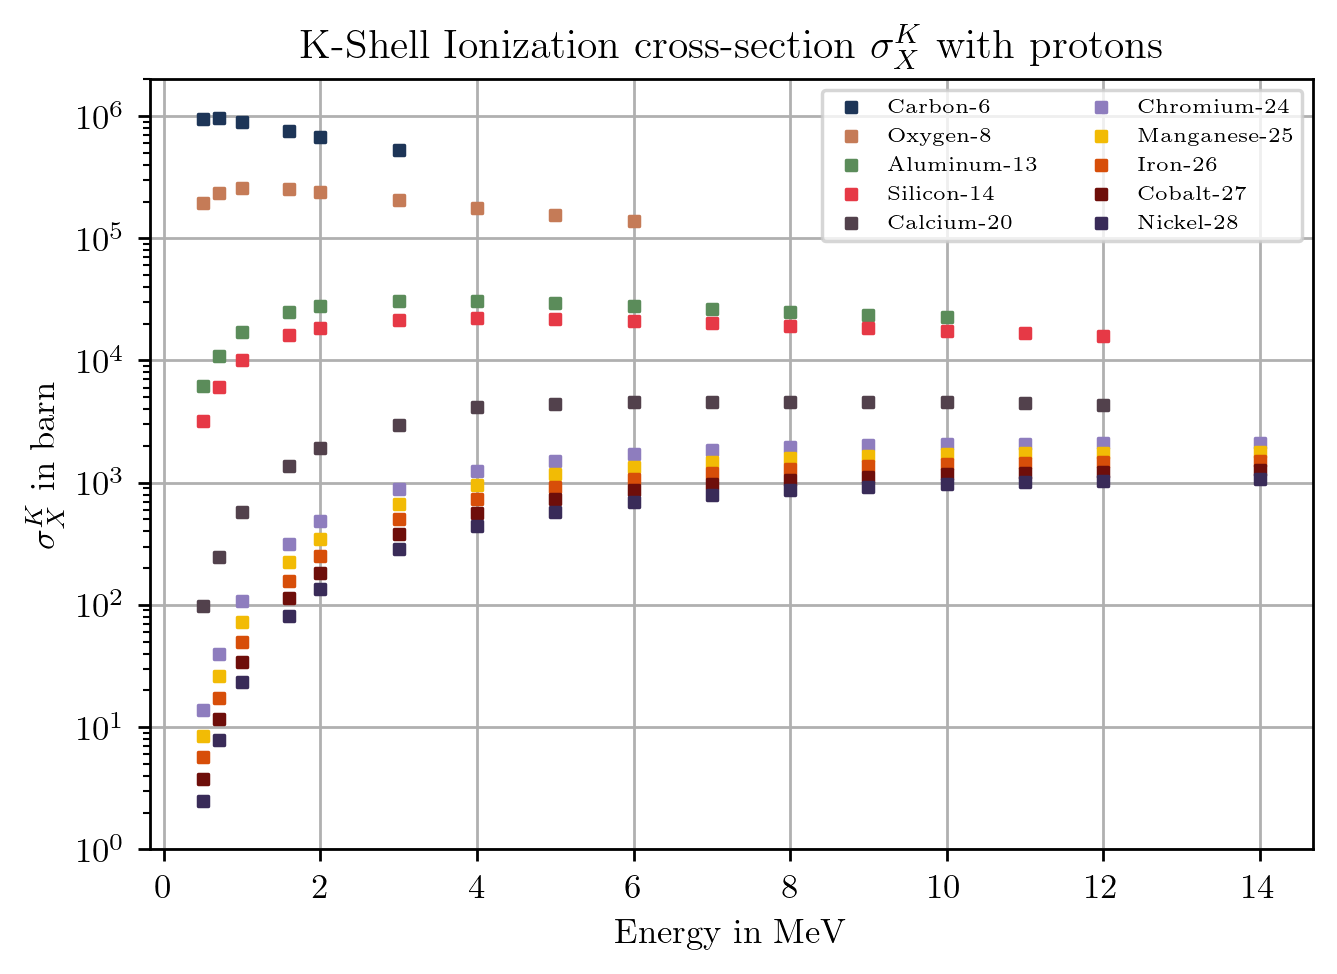

In [8]:
plt.figure(figsize=(6,4), dpi=250)
plt.scatter(data_6_C[0],data_6_C[1],label=data_6_C[2],marker='s',s=10,color='#1d3557',zorder=2)
plt.scatter(data_8_O[0],data_8_O[1],label=data_8_O[2],marker='s',s=10,color='#c57b57',zorder=2)
plt.scatter(data_13_Al[0],np.array(data_13_Al[1])*data_13_Al[3],label=data_13_Al[2],marker='s',s=10,color='#5b8c5a',zorder=2)
plt.scatter(data_14_Si[0],np.array(data_14_Si[1])*data_14_Si[3],label=data_14_Si[2],marker='s',s=10,color='#e63946',zorder=2)
plt.scatter(data_20_Ca[0],np.array(data_20_Ca[1])*data_20_Ca[3],label=data_20_Ca[2],marker='s',s=10,color='#52414c',zorder=2)
plt.scatter(data_24_Cr[0],np.array(data_24_Cr[1])*data_24_Cr[3],label=data_24_Cr[2],marker='s',s=10,color='#8e7dbe',zorder=2)
plt.scatter(data_25_Mn[0],np.array(data_25_Mn[1])*data_25_Mn[3],label=data_25_Mn[2],marker='s',s=10,color='#f2bb05',zorder=2)
plt.scatter(data_26_Fe[0],np.array(data_26_Fe[1])*data_26_Fe[3],label=data_26_Fe[2],marker='s',s=10,color='#d74e09',zorder=2)
plt.scatter(data_27_Co[0],np.array(data_27_Co[1])*data_27_Co[3],label=data_27_Co[2],marker='s',s=10,color='#6e0e0a',zorder=2)
plt.scatter(data_28_Ni[0],np.array(data_28_Ni[1])*data_28_Ni[3],label=data_28_Ni[2],marker='s',s=10,color='#392b58',zorder=2)

# plt.vlines(x=1.6,ymin=0,ymax=10**8,ls=':', lw=0.7, color='black', alpha=0.6, zorder=1)
plt.ylim(1,2*10**6)
plt.legend(loc=1, fontsize=6, ncols=2)
plt.grid()
plt.yscale('log')
plt.xlabel(r'Energy in MeV')
plt.ylabel(r'$\sigma_X^K$ in barn')
plt.title(r'K-Shell Ionization cross-section $\sigma_X^K$ with protons')
plt.show()

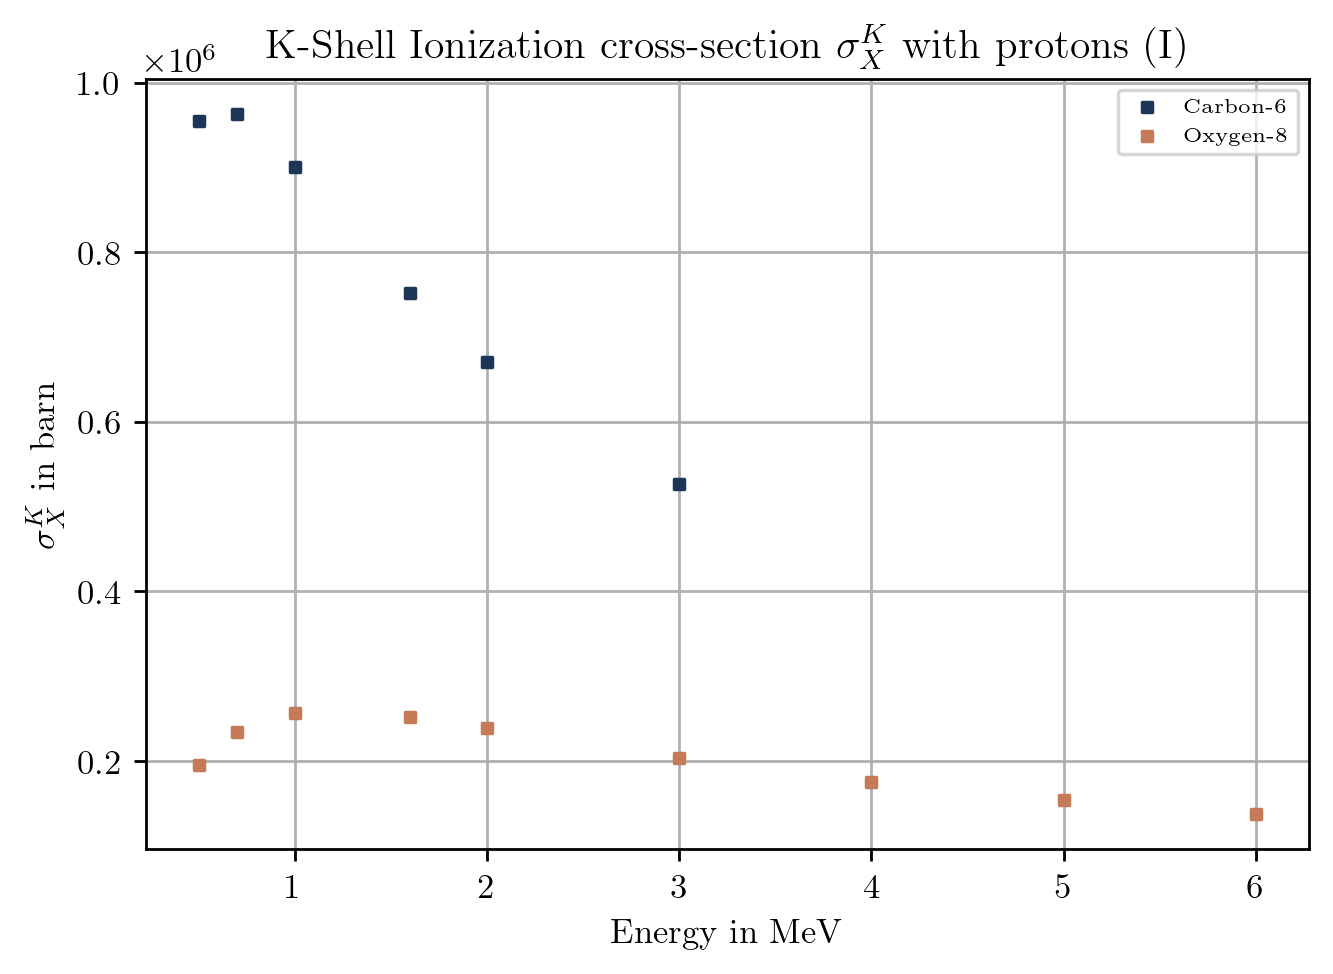

In [9]:
plt.figure(figsize=(6,4), dpi=250)
plt.scatter(data_6_C[0],data_6_C[1],label=data_6_C[2],marker='s',s=10,color='#1d3557',zorder=2)
plt.scatter(data_8_O[0],data_8_O[1],label=data_8_O[2],marker='s',s=10,color='#c57b57',zorder=2)

plt.legend(fontsize=6)
plt.grid()
# plt.yscale('log')
plt.xlabel(r'Energy in MeV')
plt.ylabel(r'$\sigma_X^K$ in barn')
plt.title(r'K-Shell Ionization cross-section $\sigma_X^K$ with protons (I)')
plt.show()

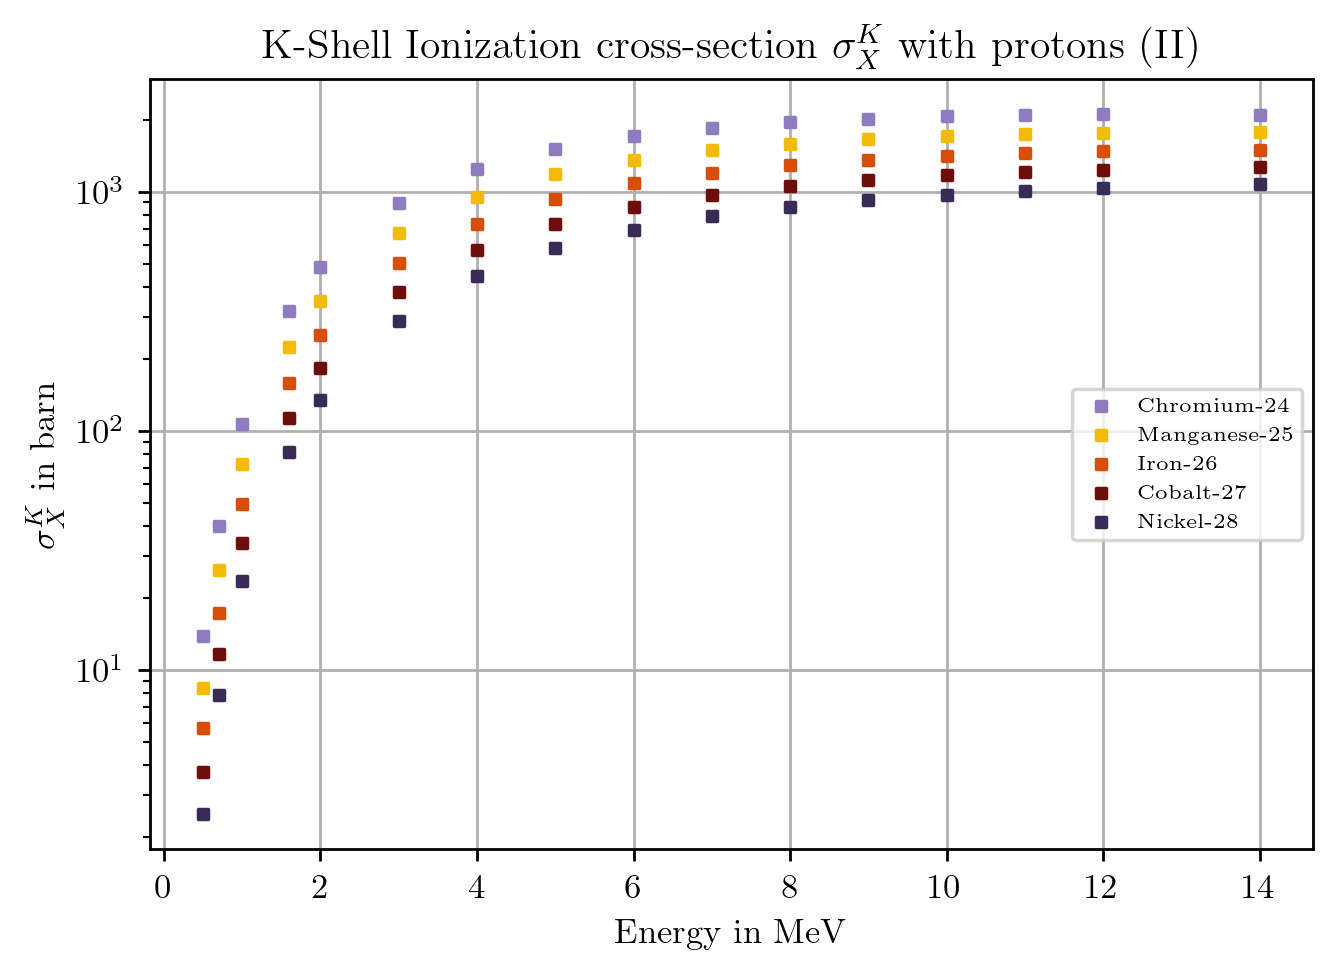

In [10]:
plt.figure(figsize=(6,4), dpi=250)
plt.scatter(data_24_Cr[0],np.array(data_24_Cr[1])*data_24_Cr[3],label=data_24_Cr[2],marker='s',s=10,color='#8e7dbe',zorder=2)
plt.scatter(data_25_Mn[0],np.array(data_25_Mn[1])*data_25_Mn[3],label=data_25_Mn[2],marker='s',s=10,color='#f2bb05',zorder=2)
plt.scatter(data_26_Fe[0],np.array(data_26_Fe[1])*data_26_Fe[3],label=data_26_Fe[2],marker='s',s=10,color='#d74e09',zorder=2)
plt.scatter(data_27_Co[0],np.array(data_27_Co[1])*data_27_Co[3],label=data_27_Co[2],marker='s',s=10,color='#6e0e0a',zorder=2)
plt.scatter(data_28_Ni[0],np.array(data_28_Ni[1])*data_28_Ni[3],label=data_28_Ni[2],marker='s',s=10,color='#392b58',zorder=2)
plt.legend(loc=7,fontsize=6)
plt.grid()
plt.yscale('log')
plt.xlabel(r'Energy in MeV')
plt.ylabel(r'$\sigma_X^K$ in barn')
plt.title(r'K-Shell Ionization cross-section $\sigma_X^K$ with protons (II)')
plt.show()

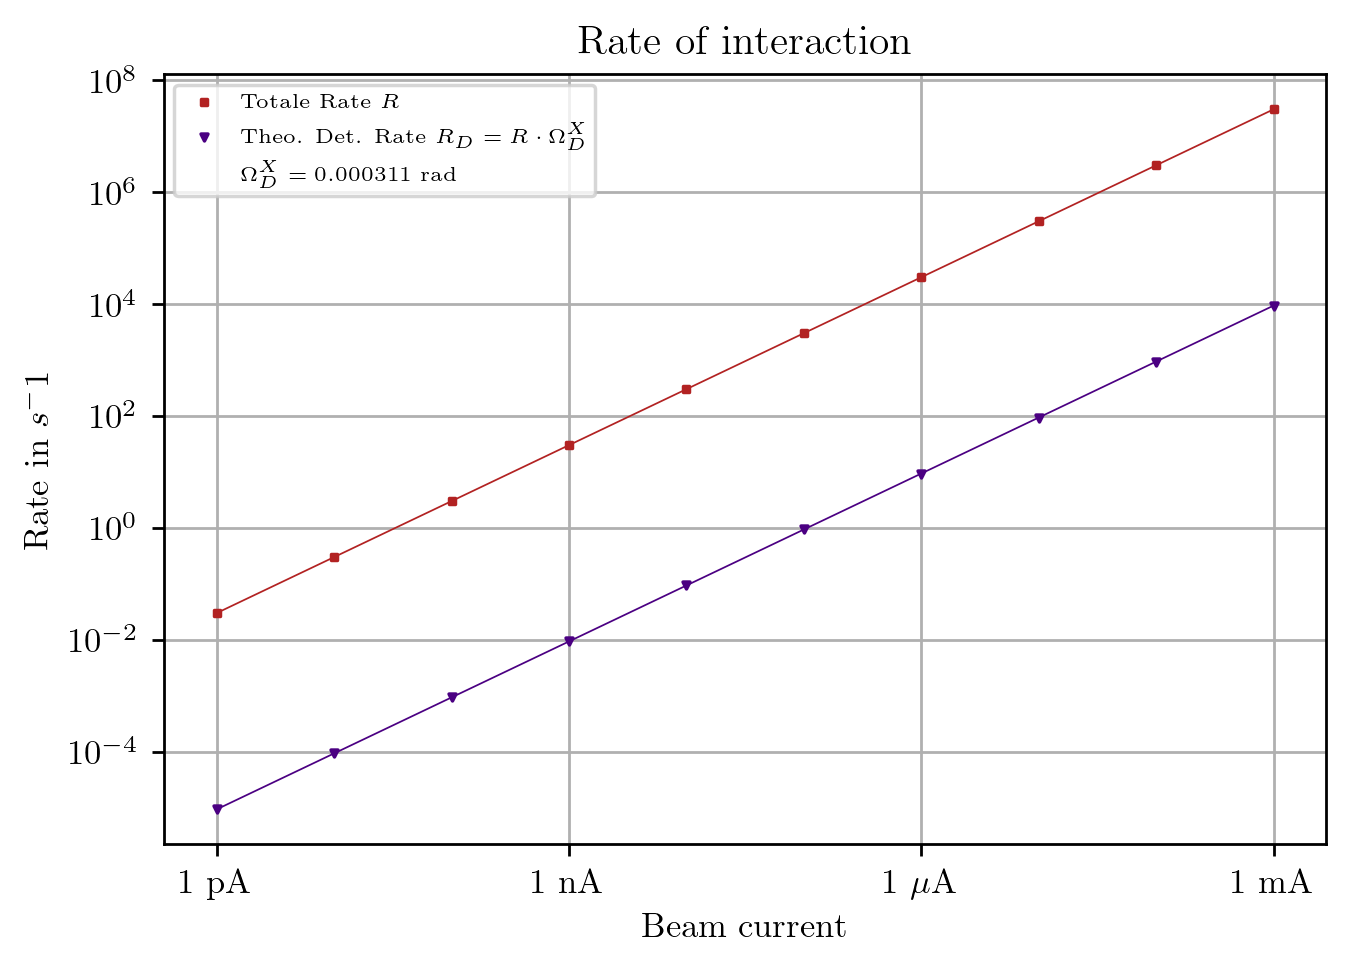

In [11]:
plt.figure(figsize=(6,4), dpi=250)
plt.scatter(dNdt*(1.602*10**(-19)),dNdt*((Fe.density*N_A)/(Fe.atomic_weight))**(2/3)*data_26_Fe[1][4]*b,zorder=2, label=r'Totale Rate $R$', marker='s', color='firebrick', s=4)
plt.scatter(dNdt*(1.602*10**(-19)),dNdt*((Fe.density*N_A)/(Fe.atomic_weight))**(2/3)*data_26_Fe[1][4]*b*0.000311,zorder=2, label=r'Theo. Det. Rate $R_D =R\cdot\Omega_D^X$', marker='v', color='indigo', s=4)
plt.plot(dNdt*(1.602*10**(-19)),dNdt*((Fe.density*N_A)/(Fe.atomic_weight))**(2/3)*data_26_Fe[1][4]*b,zorder=2, color='firebrick', lw=0.5)
plt.plot(dNdt*(1.602*10**(-19)),dNdt*((Fe.density*N_A)/(Fe.atomic_weight))**(2/3)*data_26_Fe[1][4]*b*0.000311,zorder=2, color='indigo', lw=0.5)
plt.scatter([],[],label=r'$\Omega_D^X = 0.000311$ rad', alpha=0)
plt.legend(loc=2, fontsize=6, ncols=1)
plt.grid()
plt.xscale('log')
plt.yscale('log')
plt.xticks([10**(-12),10**(-9),10**(-6),10**(-3)],['1~pA','1~nA',r'1~$\mu$A','1~mA'])
plt.xlabel(r'Beam current')
plt.ylabel(r'Rate in $s^-1$')
plt.title(r'Rate of interaction')
plt.savefig('KR_2.jpg', dpi=250)
plt.show()

In [6]:
def RfCs(E,Z1,Z2,theta,M1,M2):
    '''
    following M.Mayer, 2003 eq.(7) and (8);
    Detector-Area = 0.0133
    '''
    E = np.array(E)*1000
    prefactor = 5.1837436*10**6
    theta = theta/180*np.pi
    A = (Z1*Z2/E)**2
    B1 = np.sqrt(M2**2 - M1**2*np.sin(theta)**2)
    B2 = M2*np.cos(theta)
    B3 = M2*np.sin(theta)**4
    B4 = np.sqrt(M2**2 - M1**2*np.sin(theta)**2)
    F = 1-(0.049*Z1*(Z2)**(4/3))/(E)
    return F*prefactor*A*((B1+B2)**2)/(B3*B4)

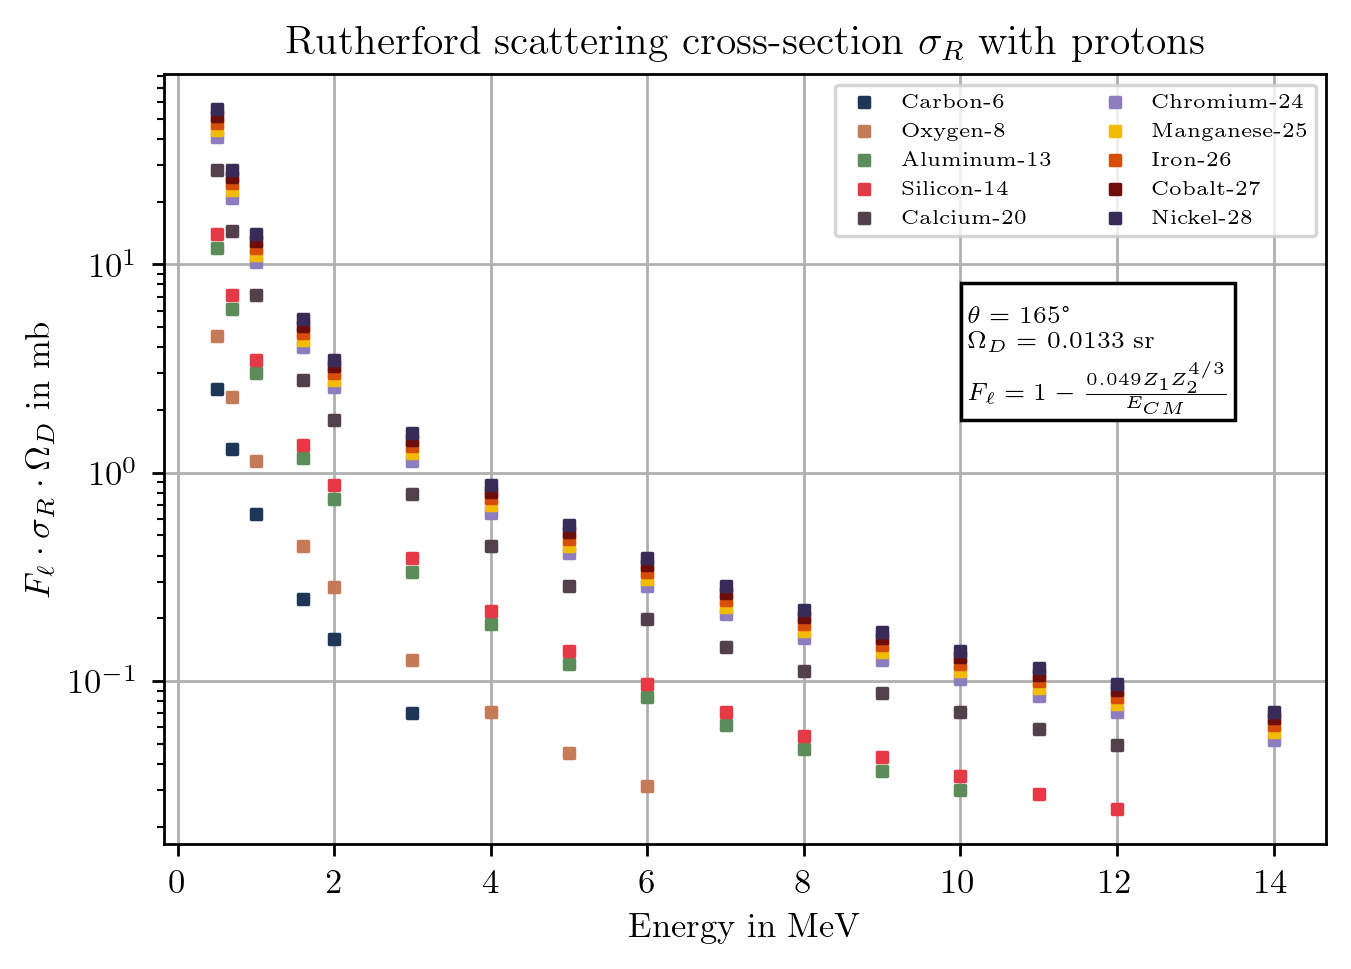

In [ ]:
def DsigDome(E,Z1,Z2,theta):
    Z1 = int(Z1)
    Z2 = int(Z2)
    E = np.array(E)
    eps = 8.854*10**(-12)
    e = 1.602*10**(-19)
    theta = theta/180*np.pi
    A = (Z1*Z2)
    B = (E*np.sin(theta/2)**2)
    return 1.3*10**(-3)*((Z1*Z2)/E)**2 * 1/(np.sin(theta/2)**4)






Theta = 165
plt.figure(figsize=(6,4), dpi=250)
plt.scatter(data_6_C[0],RfCs(data_6_C[0],1,data_6_C[4],Theta,1,C.atomic_weight),label=data_6_C[2],marker='s',s=10,color='#1d3557',zorder=2)
plt.scatter(data_8_O[0],RfCs(data_8_O[0],1,data_8_O[4],Theta,1,O.atomic_weight),label=data_8_O[2],marker='s',s=10,color='#c57b57',zorder=2)
plt.scatter(data_13_Al[0],RfCs(data_13_Al[0],1,data_13_Al[4],Theta,1,Al.atomic_weight),label=data_13_Al[2],marker='s',s=10,color='#5b8c5a',zorder=2)
plt.scatter(data_14_Si[0],RfCs(data_14_Si[0],1,data_14_Si[4],Theta,1,Si.atomic_weight),label=data_14_Si[2],marker='s',s=10,color='#e63946',zorder=2)
plt.scatter(data_20_Ca[0],RfCs(data_20_Ca[0],1,data_20_Ca[4],Theta,1,Ca.atomic_weight),label=data_20_Ca[2],marker='s',s=10,color='#52414c',zorder=2)
plt.scatter(data_24_Cr[0],RfCs(data_24_Cr[0],1,data_24_Cr[4],Theta,1,Cr.atomic_weight),label=data_24_Cr[2],marker='s',s=10,color='#8e7dbe',zorder=2)
plt.scatter(data_25_Mn[0],RfCs(data_25_Mn[0],1,data_25_Mn[4],Theta,1,Mn.atomic_weight),label=data_25_Mn[2],marker='s',s=10,color='#f2bb05',zorder=2)
plt.scatter(data_26_Fe[0],RfCs(data_26_Fe[0],1,data_26_Fe[4],Theta,1,Fe.atomic_weight),label=data_26_Fe[2],marker='s',s=10,color='#d74e09',zorder=2)
plt.scatter(data_27_Co[0],RfCs(data_27_Co[0],1,data_27_Co[4],Theta,1,Co.atomic_weight),label=data_27_Co[2],marker='s',s=10,color='#6e0e0a',zorder=2)
plt.scatter(data_28_Ni[0],RfCs(data_28_Ni[0],1,data_28_Ni[4],Theta,1,Ni.atomic_weight),label=data_28_Ni[2],marker='s',s=10,color='#392b58',zorder=2)
plt.text(x=10.1, y=4, s='\n' + r'$\theta =$ 165°' + '\n' + r'$\Omega_D =$ 0.0133 sr' + '\n' + r'$F_{\ell} = 1 - \frac{0.049Z_1Z_2^{4/3}}{E_{CM}}$', fontsize=7, va='center', bbox=dict(boxstyle="square",ec=(0., 0., 0.),fc=(1., 1., 1.)))
plt.legend(loc=1, fontsize=6, ncols=2)
plt.grid()
plt.yscale('log')
plt.xlabel(r'Energy in MeV')
plt.ylabel(r'$F_{\ell}\cdot\sigma_R\cdot\Omega_D$ in mb')
plt.title(r'Rutherford scattering cross-section $\sigma_R$ with protons')
plt.savefig('RfCS1.jpg', dpi=250)
plt.show()

331
332
333
334
335
336
337
338
339


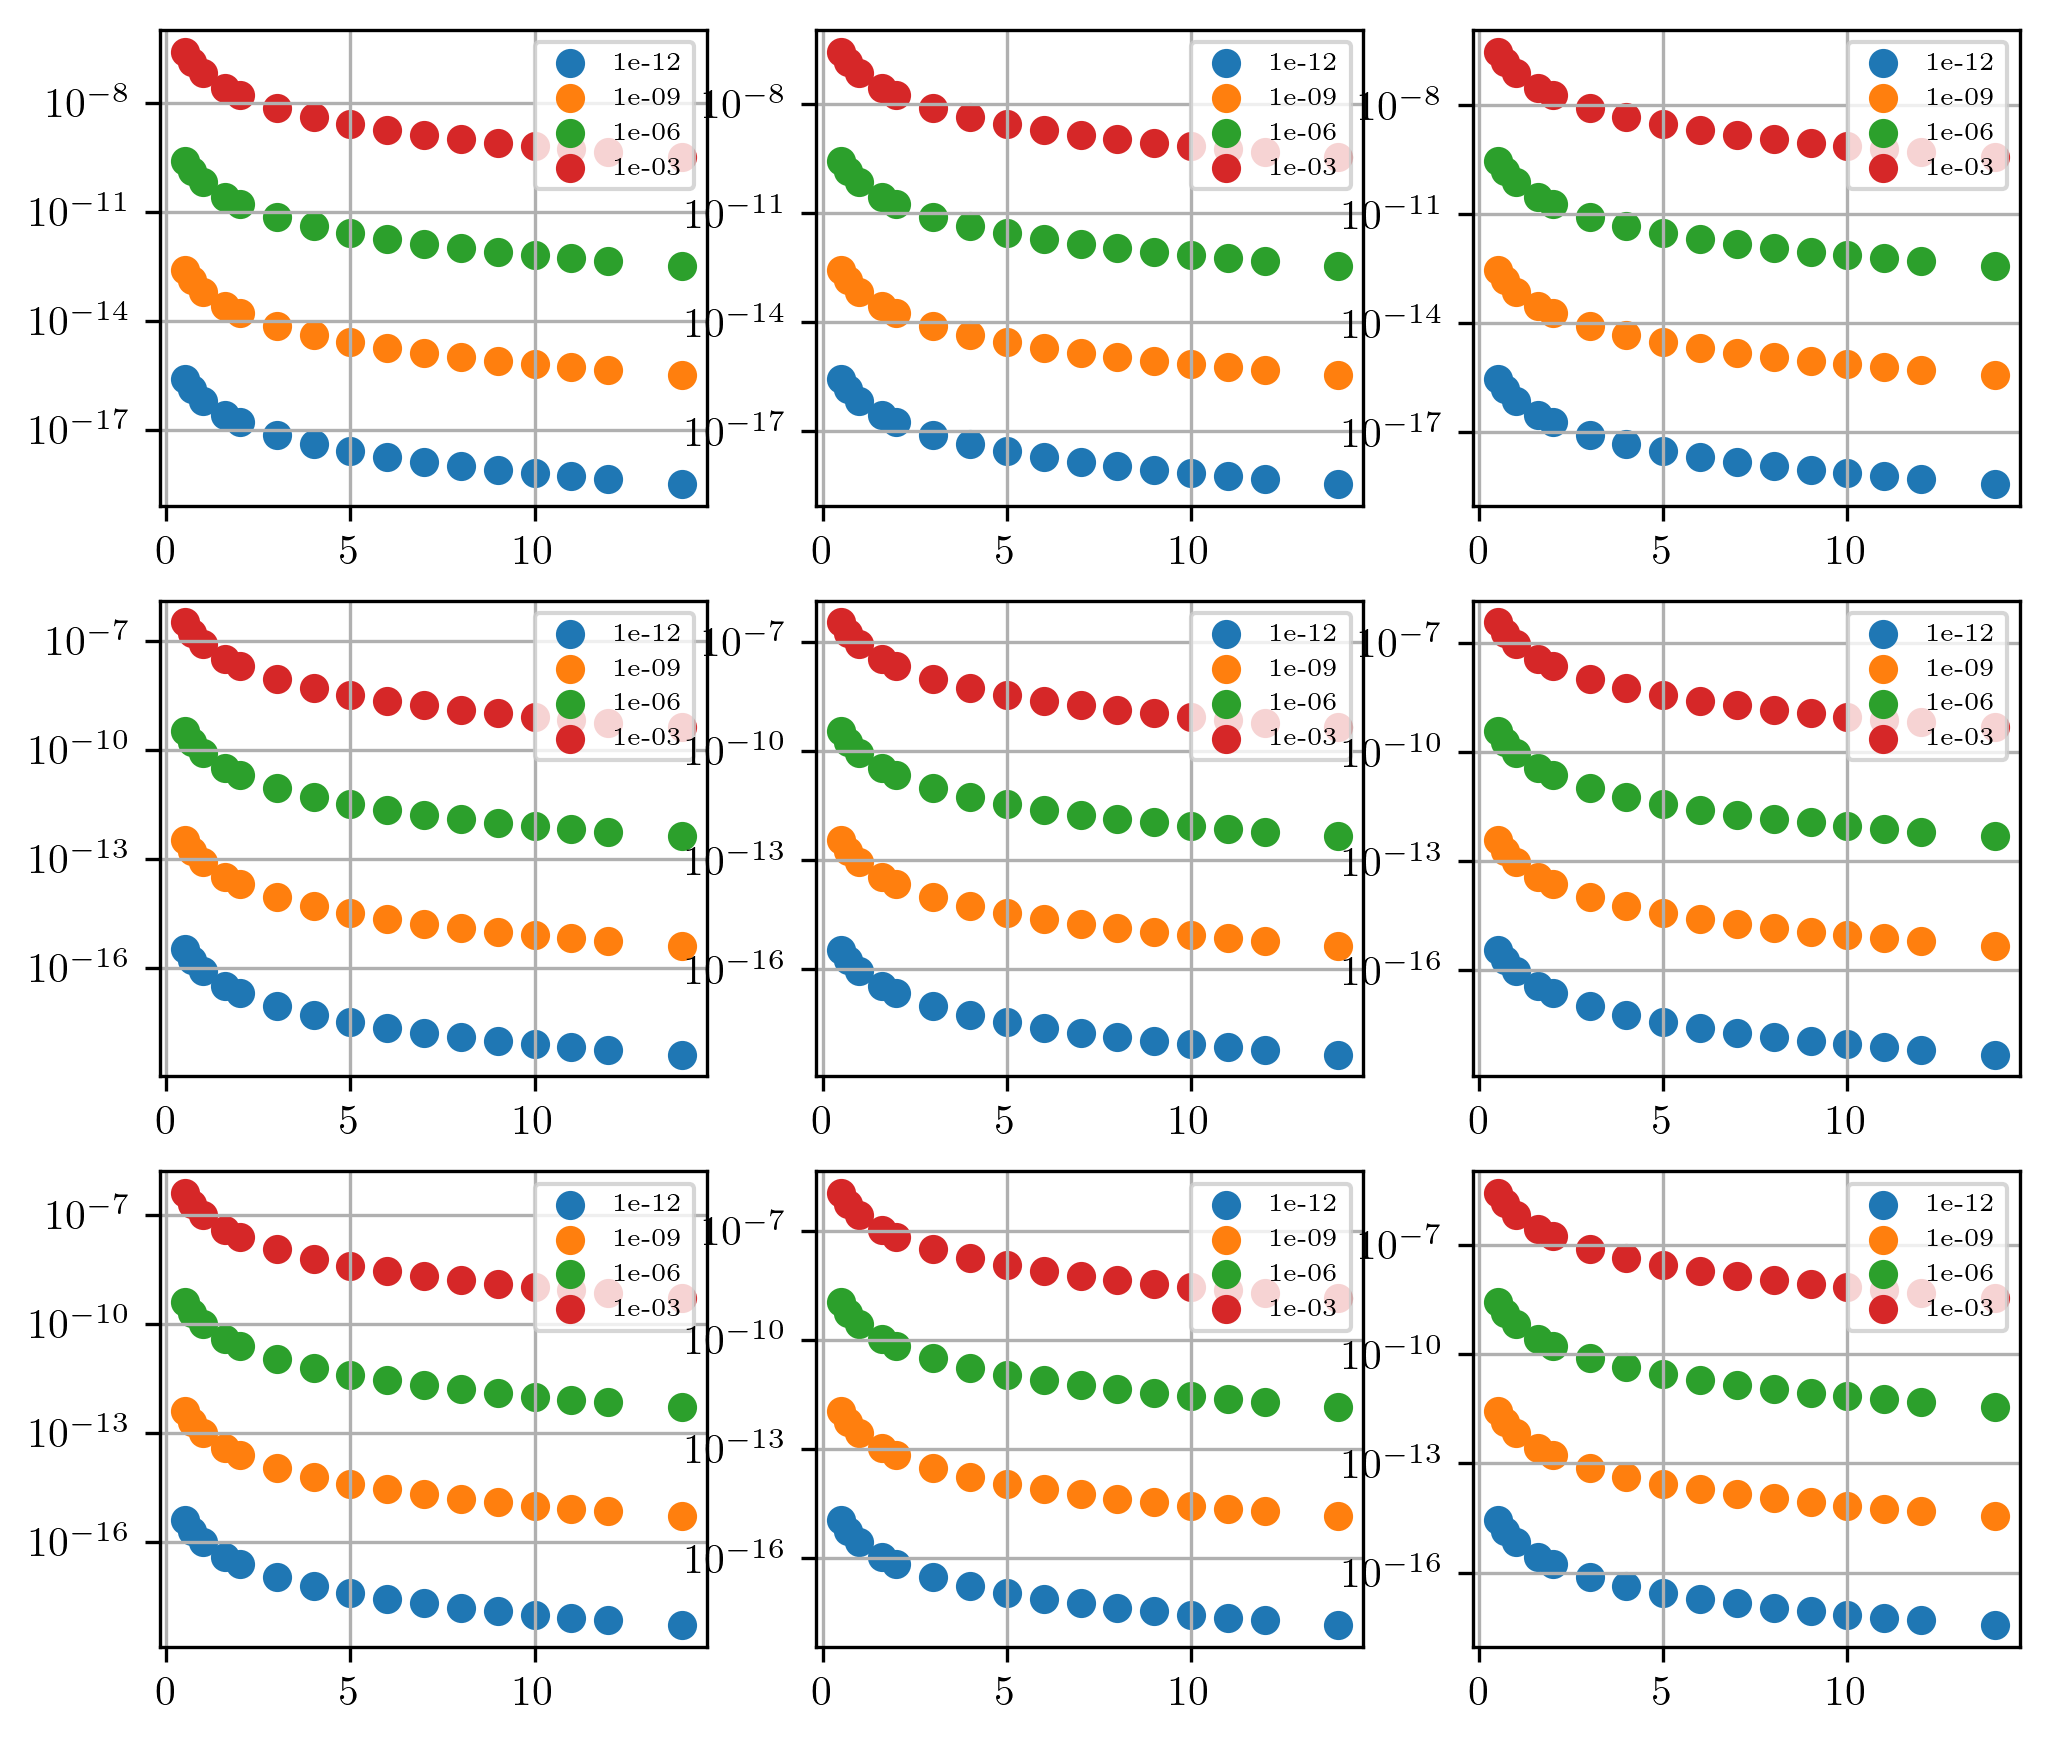

In [ ]:
Theta = 165
# data = [[C, O, Al, Si, S, Ca, Cr, Mn, Fe, Co, Ni, Cu, Zn, Sn, Au],[0.5,0.7,1,1.6,2,3,4,5,6,7,8,9,10,11,12,14],[6,8,13,14,16,20,24,25,26,27,28,29,30,50,79]]
data = [[Cr, Mn, Fe, Co, Ni, Cu, Zn, Sn, Au],[0.5,0.7,1,1.6,2,3,4,5,6,7,8,9,10,11,12,14],[24,25,26,27,28,29,30,50,79]]
plt.figure(figsize=(8,7), dpi=300)
for ele in range(len(data[0])):
    subindex = '33' + str(ele+1)
    # print(subindex)
    plt.subplot(int(subindex))
    plt.grid()
    plt.yscale('log')

    for N in dNdt[::3]:
        plt.scatter(data[1],RfCs(data[1],1,data[2][ele],Theta,1,data[0][ele].atomic_weight)*N*b*, label='{:0.0e}'.format(N*1.602*10**(-19)))
        # plt.scatter(data_6_C[0],RfCs(data_6_C[0],1,data_6_C[4],Theta,1,C.atomic_weight)*N*b,marker='s',s=10,color='#1d3557',zorder=2)
        # plt.plot(data_6_C[0],RfCs(data_6_C[0],1,data_6_C[4],Theta,1,C.atomic_weight)*N*b,label='{:0.0e}'.format(N*1.602*10**(-19)),lw=0.5,color='#1d3557',zorder=2)
    plt.legend(loc=1, fontsize=6, ncols=1)

# plt.scatter(data_13_Al[0],RfCs(data_13_Al[0],1,data_13_Al[4],Theta,1,Al.atomic_weight),label=data_13_Al[2],marker='s',s=10,color='#5b8c5a',zorder=2)
# plt.scatter(data_14_Si[0],RfCs(data_14_Si[0],1,data_14_Si[4],Theta,1,Si.atomic_weight),label=data_14_Si[2],marker='s',s=10,color='#e63946',zorder=2)
# plt.scatter(data_20_Ca[0],RfCs(data_20_Ca[0],1,data_20_Ca[4],Theta,1,Ca.atomic_weight),label=data_20_Ca[2],marker='s',s=10,color='#52414c',zorder=2)
# plt.scatter(data_24_Cr[0],RfCs(data_24_Cr[0],1,data_24_Cr[4],Theta,1,Cr.atomic_weight),label=data_24_Cr[2],marker='s',s=10,color='#8e7dbe',zorder=2)
# plt.scatter(data_25_Mn[0],RfCs(data_25_Mn[0],1,data_25_Mn[4],Theta,1,Mn.atomic_weight),label=data_25_Mn[2],marker='s',s=10,color='#f2bb05',zorder=2)
# plt.scatter(data_26_Fe[0],RfCs(data_26_Fe[0],1,data_26_Fe[4],Theta,1,Fe.atomic_weight),label=data_26_Fe[2],marker='s',s=10,color='#d74e09',zorder=2)
# plt.scatter(data_27_Co[0],RfCs(data_27_Co[0],1,data_27_Co[4],Theta,1,Co.atomic_weight),label=data_27_Co[2],marker='s',s=10,color='#6e0e0a',zorder=2)
# plt.scatter(data_28_Ni[0],RfCs(data_28_Ni[0],1,data_28_Ni[4],Theta,1,Ni.atomic_weight),label=data_28_Ni[2],marker='s',s=10,color='#392b58',zorder=2)
# plt.text(x=10.1, y=4, s='\n' + r'$\theta =$ 165°' + '\n' + r'$\Omega_D =$ 0.0133 sr' + '\n' + r'$F_{\ell} = 1 - \frac{0.049Z_1Z_2^{4/3}}{E_{CM}}$', fontsize=7, va='center', bbox=dict(boxstyle="square",ec=(0., 0., 0.),fc=(1., 1., 1.)))
# plt.legend(loc=1, fontsize=6, ncols=2)
# plt.grid()
# plt.yscale('log')
# plt.xlabel(r'Energy in MeV')
# plt.ylabel(r'$F_{\ell}\cdot\sigma_R\cdot\Omega_D$ in mb')
# plt.title(r'Rutherford scattering cross-section $\sigma_R$ with protons')
# plt.savefig('RfCS2.jpg', dpi=250)
plt.show()

In [ ]:
Theta = 165
f = dNdt[1] * np.sin(Theta/180*np.pi)*(17.5/150)**2
plt.figure(figsize=(6,4), dpi=250)
plt.scatter(data_6_C[0],DsigDome(data_6_C[0],1,data_6_C[4],Theta)*f,label=data_6_C[2],marker='s',s=10,color='#1d3557',zorder=2)
plt.scatter(data_8_O[0],DsigDome(data_8_O[0],1,data_8_O[4],Theta)*f,label=data_8_O[2],marker='s',s=10,color='#c57b57',zorder=2)
plt.scatter(data_13_Al[0],DsigDome(data_13_Al[0],1,data_13_Al[4],Theta)*f,label=data_13_Al[2],marker='s',s=10,color='#5b8c5a',zorder=2)
plt.scatter(data_14_Si[0],DsigDome(data_14_Si[0],1,data_14_Si[4],Theta)*f,label=data_14_Si[2],marker='s',s=10,color='#e63946',zorder=2)
plt.scatter(data_20_Ca[0],DsigDome(data_20_Ca[0],1,data_20_Ca[4],Theta)*f,label=data_20_Ca[2],marker='s',s=10,color='#52414c',zorder=2)
plt.scatter(data_24_Cr[0],DsigDome(data_24_Cr[0],1,data_24_Cr[4],Theta)*f,label=data_24_Cr[2],marker='s',s=10,color='#8e7dbe',zorder=2)
plt.scatter(data_25_Mn[0],DsigDome(data_25_Mn[0],1,data_25_Mn[4],Theta)*f,label=data_25_Mn[2],marker='s',s=10,color='#f2bb05',zorder=2)
plt.scatter(data_26_Fe[0],DsigDome(data_26_Fe[0],1,data_26_Fe[4],Theta)*f,label=data_26_Fe[2],marker='s',s=10,color='#d74e09',zorder=2)
plt.scatter(data_27_Co[0],DsigDome(data_27_Co[0],1,data_27_Co[4],Theta)*f,label=data_27_Co[2],marker='s',s=10,color='#6e0e0a',zorder=2)
plt.scatter(data_28_Ni[0],DsigDome(data_28_Ni[0],1,data_28_Ni[4],Theta)*f,label=data_28_Ni[2],marker='s',s=10,color='#392b58',zorder=2)

plt.legend(loc=1, fontsize=6, ncols=2)
plt.grid()
plt.yscale('log')
plt.xlabel(r'Energy in MeV')
plt.ylabel(r'$\sigma_R$ in barn')
plt.title(r'Rutherford scattering cross-section $\sigma_R$ with protons')
plt.savefig('RfCS2.jpg', dpi=250)
plt.show()

In [4]:
def RfData():
    # E9 = np.linspace(0.7,1.4,71) #proton
    # E3 = np.linspace(7,14,71) #proton
    E9 = np.linspace(2.8,6,81) #alpha
    E3 = np.linspace(14,28,71) #alpha
    data3,data9 = [],[]
    names = []
    
    for i in range(1,119):
        M1 = mdl.element(2).atomic_weight #He4
        M2 = mdl.element(i).atomic_weight
        Z1 = 2
        Z2 = mdl.element(i).protons
        theta = 170
        xsection_3 = list(RfCs(E3,Z1,Z2,theta,M1,M2))
        xsection_9 = list(RfCs(E9,Z1,Z2,theta,M1,M2))
        data3.append(xsection_3)
        data9.append(xsection_9)
        names.append(mdl.element(i).name)
        if (i%10 == 0):
            print(f'{mdl.element(i).name} has just been calculated.')
    
    df3 = pd.DataFrame(data3, index=names, columns=E3)
    df9 = pd.DataFrame(data9, index=names, columns=E9)
    # df3.to_excel('Rxsection_h3_alpha.xlsx')
    df9.to_excel('Rxsection_h9_alpha_2.xlsx')
    return data3,data9


In [7]:
data3,data9 = RfData()
# print(data[:,0])

Neon has just been calculated.
Calcium has just been calculated.
Zinc has just been calculated.
Zirconium has just been calculated.
Tin has just been calculated.
Neodymium has just been calculated.
Ytterbium has just been calculated.
Mercury has just been calculated.
Thorium has just been calculated.
Fermium has just been calculated.
Darmstadtium has just been calculated.


In [ ]:
e = 1.602*10**(-19)
print((20*10**(-6)*0.000826)/(2*e))
print((10**(-8)*0.000826)/e)
print(300/(4*np.pi*170**2)) # RBS detector size for SimNRA

51560549313.3583
51560549.31335831
0.0008260637184700451


In [23]:
# concentration calculation for YBCO from spectrum
I_Y_10 = 12205
I_Ba_10 = 50340
I_Cu_10 = 20191
# I_O_10 = 3947
I_O_10 = 3947 - 347

I_Y_100 = 101610
I_Ba_100 = 452054
I_Cu_100 = 157977
# I_O_100 = 14829
I_O_100 = 13987

I_Y_10_err = 110
I_Ba_10_err = 224
I_Cu_10_err = 142
# I_O_10_err = 62
I_O_10_err = 60

I_Y_100_err = 318
I_Ba_100_err = 672
I_Cu_100_err = 397
# I_O_100_err = 121
I_O_100_err = 118

#for 4 MeV
sigma_Y = 496.742
sigma_Ba = 1024.5
sigma_Cu = 273.9
sigma_O = 18.5285

sigma_Y_err = 49.6742
sigma_Ba_err = 102.45
sigma_Cu_err = 27.39
sigma_O_err = 1.85285

#for 2 MeV
sigma_Y2 = 1980.51
sigma_Ba2 = 4076.36
sigma_Cu2 = 1093.21
sigma_O2 = 74.0848

sigma_Y2_err = 198.051
sigma_Ba2_err = 407.636
sigma_Cu2_err = 109.321
sigma_O2_err = 7.40848

In [24]:
print('Yttrium fixed to 1')
print('------------------------------------------')
print('Barium, 10mu:',(I_Ba_10)/(I_Y_10)* (sigma_Y)/(sigma_Ba))
Ba_10_err = np.sqrt((I_Ba_10_err * I_Y_10**(-1) * sigma_Y * sigma_Ba**(-1))**2 + (I_Ba_10 * I_Y_10**(-2) * I_Y_10_err * sigma_Y * sigma_Ba**(-1))**2 + 
                    (I_Ba_10 * I_Y_10**(-1) * sigma_Y_err * sigma_Ba**(-1))**2 + (I_Ba_10 * I_Y_10**(-1) * sigma_Y * sigma_Ba**(-2) * sigma_Ba_err)**2)
print('Copper, 10mu:',(I_Cu_10)/(I_Y_10)* (sigma_Y)/(sigma_Cu))
Cu_10_err = np.sqrt((I_Cu_10_err * I_Y_10**(-1) * sigma_Y * sigma_Cu**(-1))**2 + (I_Cu_10 * I_Y_10**(-2) * I_Y_10_err * sigma_Y * sigma_Cu**(-1))**2 + 
                    (I_Cu_10 * I_Y_10**(-1) * sigma_Y_err * sigma_Cu**(-1))**2 + (I_Cu_10 * I_Y_10**(-1) * sigma_Y * sigma_Cu**(-2) * sigma_Cu_err)**2)
print('Oxygen, 10mu:',(I_O_10)/(I_Y_10)* (sigma_Y)/(sigma_O))
O_10_err = np.sqrt((I_O_10_err * I_Y_10**(-1) * sigma_Y * sigma_O**(-1))**2 + (I_O_10 * I_Y_10**(-2) * I_Y_10_err * sigma_Y * sigma_O**(-1))**2 + 
                    (I_O_10 * I_Y_10**(-1) * sigma_Y_err * sigma_O**(-1))**2 + (I_O_10 * I_Y_10**(-1) * sigma_Y * sigma_O**(-2) * sigma_O_err)**2)
print('-------------------------')
print('Barium err, 10mu:', Ba_10_err)
print('Copper err, 10mu:', Cu_10_err)
print('Oxygen err, 10mu:', O_10_err)
print('------------------------------------------')
print('Barium, 100mu:',(I_Ba_100)/(I_Y_100)* (sigma_Y)/(sigma_Ba))
Ba_100_err = np.sqrt((I_Ba_100_err * I_Y_100**(-1) * sigma_Y * sigma_Ba**(-1))**2 + (I_Ba_100 * I_Y_100**(-2) * I_Y_100_err * sigma_Y * sigma_Ba**(-1))**2 + 
                    (I_Ba_100 * I_Y_100**(-1) * sigma_Y_err * sigma_Ba**(-1))**2 + (I_Ba_100 * I_Y_100**(-1) * sigma_Y * sigma_Ba**(-2) * sigma_Ba_err)**2)
print('Copper, 100mu:',(I_Cu_100)/(I_Y_100)* (sigma_Y)/(sigma_Cu))
Cu_100_err = np.sqrt((I_Cu_100_err * I_Y_100**(-1) * sigma_Y * sigma_Cu**(-1))**2 + (I_Cu_10 * I_Y_100**(-2) * I_Y_100_err * sigma_Y * sigma_Cu**(-1))**2 + 
                    (I_Cu_100 * I_Y_100**(-1) * sigma_Y_err * sigma_Cu**(-1))**2 + (I_Cu_100 * I_Y_100**(-1) * sigma_Y * sigma_Cu**(-2) * sigma_Cu_err)**2)
print('Oxygen, 100mu:',(I_O_100)/(I_Y_100)* (sigma_Y)/(sigma_O))
O_100_err = np.sqrt((I_O_100_err * I_Y_100**(-1) * sigma_Y * sigma_O**(-1))**2 + (I_O_100 * I_Y_100**(-2) * I_Y_100_err * sigma_Y * sigma_O**(-1))**2 + 
                    (I_O_100 * I_Y_100**(-1) * sigma_Y_err * sigma_O**(-1))**2 + (I_O_100 * I_Y_100**(-1) * sigma_Y * sigma_O**(-2) * sigma_O_err)**2)
print('-------------------------')
print('Barium err, 100mu:', Ba_100_err)
print('Copper err, 100mu:', Cu_100_err)
print('Oxygen err, 100mu:', O_100_err)

Yttrium fixed to 1
------------------------------------------
Barium, 10mu: 1.9998358352282237
Copper, 10mu: 3.0002600164914255
Oxygen, 10mu: 7.907793807290267
-------------------------
Barium err, 10mu: 0.2835329202220879
Copper err, 10mu: 0.42568487537813876
Oxygen err, 10mu: 1.128323484820989
------------------------------------------
Barium, 100mu: 2.1571124425111012
Copper, 100mu: 2.8196568627355867
Oxygen, 100mu: 3.6904450506491444
-------------------------
Barium err, 100mu: 0.305153304798404
Copper err, 100mu: 0.39882424450421006
Oxygen err, 100mu: 0.5229631151142847


In [25]:
print('Oxygen fixed to 6.93')
print('------------------------------------------')
print('Barium, 10mu:',(I_Ba_10)/(I_O_10)* (sigma_O)/(sigma_Ba) * 6.93)
Ba_10_err = np.sqrt((I_Ba_10_err * I_O_10**(-1) * sigma_O * sigma_Ba**(-1))**2 + (I_Ba_10 * I_O_10**(-2) * I_O_10_err * sigma_O * sigma_Ba**(-1))**2 + 
                    (I_Ba_10 * I_O_10**(-1) * sigma_O_err * sigma_Ba**(-1))**2 + (I_Ba_10 * I_O_10**(-1) * sigma_O * sigma_Ba**(-2) * sigma_Ba_err)**2)
print('Copper, 10mu:',(I_Cu_10)/(I_O_10)* (sigma_O)/(sigma_Cu) * 6.93)
Cu_10_err = np.sqrt((I_Cu_10_err * I_O_10**(-1) * sigma_O * sigma_Cu**(-1))**2 + (I_Cu_10 * I_O_10**(-2) * I_O_10_err * sigma_O * sigma_Cu**(-1))**2 + 
                    (I_Cu_10 * I_O_10**(-1) * sigma_O_err * sigma_Cu**(-1))**2 + (I_Cu_10 * I_O_10**(-1) * sigma_O * sigma_Cu**(-2) * sigma_Cu_err)**2)
print('Yttrium, 10mu:',(I_Y_10)/(I_O_10)* (sigma_O)/(sigma_Y) * 6.93)
Y_10_err = np.sqrt((I_Y_10_err * I_O_10**(-1) * sigma_O * sigma_Y**(-1))**2 + (I_Y_10 * I_O_10**(-2) * I_O_10_err * sigma_O * sigma_Y**(-1))**2 + 
                    (I_Y_10 * I_O_10**(-1) * sigma_O_err * sigma_Y**(-1))**2 + (I_Y_10 * I_O_10**(-1) * sigma_O * sigma_Y**(-2) * sigma_Y_err)**2)
print('-------------------------')
print('Barium err, 10mu:', Ba_10_err * 6.93)
print('Copper err, 10mu:', Cu_10_err * 6.93)
print('Yttrium err, 10mu:', Y_10_err * 6.93)
print('------------------------------------------')
print('Barium, 100mu:',(I_Ba_100)/(I_O_100)* (sigma_O)/(sigma_Ba) * 6.93)
Ba_100_err = np.sqrt((I_Ba_100_err * I_O_100**(-1) * sigma_O * sigma_Ba**(-1))**2 + (I_Ba_100 * I_O_100**(-2) * I_O_100_err * sigma_O * sigma_Ba**(-1))**2 + 
                    (I_Ba_100 * I_O_100**(-1) * sigma_O_err * sigma_Ba**(-1))**2 + (I_Ba_100 * I_O_100**(-1) * sigma_O * sigma_Ba**(-2) * sigma_Ba_err)**2)
print('Copper, 100mu:',(I_Cu_100)/(I_O_100)* (sigma_O)/(sigma_Cu) * 6.93)
Cu_100_err = np.sqrt((I_Cu_100_err * I_O_100**(-1) * sigma_O * sigma_Cu**(-1))**2 + (I_Cu_10 * I_O_100**(-2) * I_O_100_err * sigma_O * sigma_Cu**(-1))**2 + 
                    (I_Cu_100 * I_O_100**(-1) * sigma_O_err * sigma_Cu**(-1))**2 + (I_Cu_100 * I_O_100**(-1) * sigma_O * sigma_Cu**(-2) * sigma_Cu_err)**2)
print('Yttrium, 100mu:',(I_Y_100)/(I_O_100)* (sigma_O)/(sigma_Y) * 6.93)
Y_100_err = np.sqrt((I_Y_100_err * I_O_100**(-1) * sigma_O * sigma_Y**(-1))**2 + (I_Y_100 * I_O_100**(-2) * I_O_100_err * sigma_O * sigma_Y**(-1))**2 + 
                    (I_Y_100 * I_O_100**(-1) * sigma_O_err * sigma_Y**(-1))**2 + (I_Y_100 * I_O_100**(-1) * sigma_O * sigma_Y**(-2) * sigma_Y_err)**2)
print('-------------------------')
print('Barium err, 100mu:', Ba_100_err * 6.93)
print('Copper err, 100mu:', Cu_100_err * 6.93)
print('Yttrium err, 100mu:', Y_100_err * 6.93)

Oxygen fixed to 6.93
------------------------------------------
Barium, 10mu: 1.7525573726207906
Copper, 10mu: 2.6292797233935743
Yttrium, 10mu: 0.8763506192600989
-------------------------
Barium err, 10mu: 0.24968609283881524
Copper err, 10mu: 0.37486594148891467
Yttrium err, 10mu: 0.1250420798449495
------------------------------------------
Barium, 100mu: 4.050673840536512
Copper, 100mu: 5.294814525234706
Yttrium, 100mu: 1.8778222964682871
-------------------------
Barium err, 100mu: 0.5739017620703648
Copper err, 100mu: 0.7489398247968552
Yttrium err, 100mu: 0.266101184088726


In [26]:
print('Barium fixed to 2')
print('------------------------------------------')
print('Oxygen, 10mu:',(I_O_10)/(I_Ba_10)* (sigma_Ba)/(sigma_O) * 2)
O_10_err = np.sqrt((I_O_10_err * I_Ba_10**(-1) * sigma_Ba * sigma_O**(-1))**2 + (I_O_10 * I_Ba_10**(-2) * I_Ba_10_err * sigma_Ba * sigma_O**(-1))**2 + 
                    (I_O_10 * I_Ba_10**(-1) * sigma_Ba_err * sigma_O**(-1))**2 + (I_O_10 * I_Ba_10**(-1) * sigma_Ba * sigma_O**(-2) * sigma_O_err)**2)
print('Copper, 10mu:',(I_Cu_10)/(I_Ba_10)* (sigma_Ba)/(sigma_Cu) * 2)
Cu_10_err = np.sqrt((I_Cu_10_err * I_Ba_10**(-1) * sigma_Ba * sigma_Cu**(-1))**2 + (I_Cu_10 * I_Ba_10**(-2) * I_Ba_10_err * sigma_Ba * sigma_Cu**(-1))**2 + 
                    (I_Cu_10 * I_Ba_10**(-1) * sigma_Ba_err * sigma_Cu**(-1))**2 + (I_Cu_10 * I_Ba_10**(-1) * sigma_Ba * sigma_Cu**(-2) * sigma_Cu_err)**2)
print('Yttrium, 10mu:',(I_Y_10)/(I_Ba_10)* (sigma_Ba)/(sigma_Y) * 2)
Y_10_err = np.sqrt((I_Y_10_err * I_Ba_10**(-1) * sigma_Ba * sigma_Y**(-1))**2 + (I_Y_10 * I_Ba_10**(-2) * I_Ba_10_err * sigma_Ba * sigma_Y**(-1))**2 + 
                    (I_Y_10 * I_Ba_10**(-1) * sigma_Ba_err * sigma_Y**(-1))**2 + (I_Y_10 * I_Ba_10**(-1) * sigma_Ba * sigma_Y**(-2) * sigma_Y_err)**2)
print('-------------------------')
print('Oxygen err, 10mu:', O_10_err * 2)
print('Copper err, 10mu:', Cu_10_err * 2)
print('Yttrium err, 10mu:', Y_10_err * 2)
print('------------------------------------------')
print('Oxygen, 100mu:',(I_O_100)/(I_Ba_100)* (sigma_Ba)/(sigma_O) * 2)
O_100_err = np.sqrt((I_O_100_err * I_Ba_100**(-1) * sigma_Ba * sigma_O**(-1))**2 + (I_O_100 * I_Ba_100**(-2) * I_Ba_100_err * sigma_Ba * sigma_O**(-1))**2 + 
                    (I_O_100 * I_Ba_100**(-1) * sigma_Ba_err * sigma_O**(-1))**2 + (I_O_100 * I_Ba_100**(-1) * sigma_Ba * sigma_O**(-2) * sigma_O_err)**2)
print('Copper, 100mu:',(I_Cu_100)/(I_Ba_100)* (sigma_Ba)/(sigma_Cu) * 2)
Cu_100_err = np.sqrt((I_Cu_100_err * I_Ba_100**(-1) * sigma_Ba * sigma_Cu**(-1))**2 + (I_Cu_10 * I_Ba_100**(-2) * I_Ba_100_err * sigma_Ba * sigma_Cu**(-1))**2 + 
                    (I_Cu_100 * I_Ba_100**(-1) * sigma_Ba_err * sigma_Cu**(-1))**2 + (I_Cu_100 * I_Ba_100**(-1) * sigma_Ba * sigma_Cu**(-2) * sigma_Cu_err)**2)
print('Yttrium, 100mu:',(I_Y_100)/(I_Ba_100)* (sigma_Ba)/(sigma_Y) * 2)
Y_100_err = np.sqrt((I_Y_100_err * I_Ba_100**(-1) * sigma_Ba * sigma_Y**(-1))**2 + (I_Y_100 * I_Ba_100**(-2) * I_Ba_100_err * sigma_Ba * sigma_Y**(-1))**2 + 
                    (I_Y_100 * I_Ba_100**(-1) * sigma_Ba_err * sigma_Y**(-1))**2 + (I_Y_100 * I_Ba_100**(-1) * sigma_Ba * sigma_Y**(-2) * sigma_Y_err)**2)
print('-------------------------')
print('Oxygen err, 100mu:', O_100_err * 2)
print('Copper err, 100mu:', Cu_100_err * 2)
print('Yttrium err, 100mu:', Y_100_err * 2)

Barium fixed to 2
------------------------------------------
Oxygen, 10mu: 7.908442951156359
Copper, 10mu: 3.000506305207829
Yttrium, 10mu: 1.0000820891239595
-------------------------
Oxygen err, 10mu: 1.12671245561566
Copper err, 10mu: 0.42506978377681415
Yttrium err, 10mu: 0.14178973603538958
------------------------------------------
Oxygen, 100mu: 3.421652926310217
Copper, 100mu: 2.6142882560662595
Yttrium, 100mu: 0.9271653904475161
-------------------------
Oxygen err, 100mu: 0.48478172296947075
Copper err, 100mu: 0.3697748913834168
Yttrium err, 100mu: 0.1311603314755374


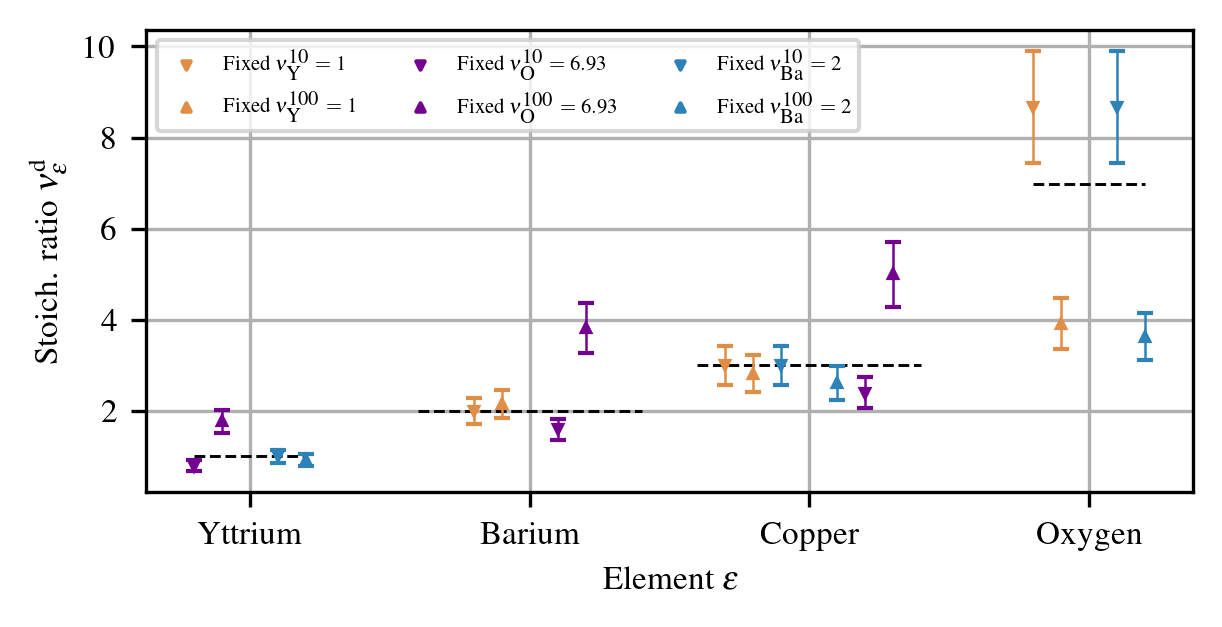

In [13]:
Yttrium = [0.799,1.771,1.000,0.927]
Oxygen = [8.67,3.913,8.671,3.628]
Barium = [2.000,2.157,1.598,3.821]
Copper = [3.000,2.820,2.398,4.994,3.001,2.614]

Yttrium_err = [0.114,0.251,0.142,0.131]
Oxygen_err = [1.236,0.554,1.234,0.514]
Barium_err = [0.284,0.305,0.228,0.541]
Copper_err = [0.426,0.399,0.342,0.706,0.425,0.370]

colors = ['#690000','#c1292e','#e08e45','#E0BE36','#7A8C2A','#14591d','#2d82b7','#740091']
plt.figure(figsize=(4.5,2), dpi=300)
# plt.scatter([1,1.5,2,2.5],[1,2,3,6.97], s=10, color='black', marker='x', zorder=2)
plt.errorbar(0.9,Yttrium[0], yerr=Yttrium_err[0], color=colors[7], lw=0.6, capsize=2,fmt='v', markersize=2, zorder=3, alpha=1)
plt.errorbar(0.95,Yttrium[1], yerr=Yttrium_err[1], color=colors[7], lw=0.6, capsize=2,fmt='^', markersize=2, zorder=3, alpha=1)
plt.errorbar(1.05,Yttrium[2], yerr=Yttrium_err[2], color=colors[6], lw=0.6, capsize=2,fmt='v', markersize=2, zorder=3, alpha=1)
plt.errorbar(1.1,Yttrium[3], yerr=Yttrium_err[3], color=colors[6], lw=0.6, capsize=2,fmt='^', markersize=2, zorder=3, alpha=1)


plt.errorbar(1.4,Barium[0], yerr=Barium_err[0], color=colors[2], lw=0.6, capsize=2,fmt='v', markersize=2, zorder=3, alpha=1)
plt.errorbar(1.45,Barium[1], yerr=Barium_err[1], color=colors[2], lw=0.6, capsize=2,fmt='^', markersize=2, zorder=3, alpha=1)

plt.errorbar(1.55,Barium[2], yerr=Barium_err[2], color=colors[7], lw=0.6, capsize=2,fmt='v', markersize=2, zorder=3, alpha=1)
plt.errorbar(1.6,Barium[3], yerr=Barium_err[3], color=colors[7], lw=0.6, capsize=2,fmt='^', markersize=2, zorder=3, alpha=1)

plt.errorbar(1.85,Copper[0], yerr=Copper_err[0], color=colors[2], lw=0.6, capsize=2,fmt='v', markersize=2, zorder=3, alpha=1)
plt.errorbar(1.9,Copper[1], yerr=Copper_err[1], color=colors[2], lw=0.6, capsize=2,fmt='^', markersize=2, zorder=3, alpha=1)

plt.errorbar(1.95,Copper[4], yerr=Copper_err[4], color=colors[6], lw=0.6, capsize=2,fmt='v', markersize=2, zorder=3, alpha=1)
plt.errorbar(2.05,Copper[5], yerr=Copper_err[5], color=colors[6], lw=0.6, capsize=2,fmt='^', markersize=2, zorder=3, alpha=1)

plt.errorbar(2.1,Copper[2], yerr=Copper_err[2], color=colors[7], lw=0.6, capsize=2,fmt='v', markersize=2, zorder=3, alpha=1)
plt.errorbar(2.15,Copper[3], yerr=Copper_err[3], color=colors[7], lw=0.6, capsize=2,fmt='^', markersize=2, zorder=3, alpha=1)

plt.errorbar(2.4,Oxygen[0], yerr=Oxygen_err[0], color=colors[2], lw=0.6, capsize=2,fmt='v', markersize=2, zorder=3, alpha=1)
plt.errorbar(2.45,Oxygen[1], yerr=Oxygen_err[1], color=colors[2], lw=0.6, capsize=2,fmt='^', markersize=2, zorder=3, alpha=1)
plt.errorbar(2.55,Oxygen[2], yerr=Oxygen_err[2], color=colors[6], lw=0.6, capsize=2,fmt='v', markersize=2, zorder=3, alpha=1)
plt.errorbar(2.6,Oxygen[3], yerr=Oxygen_err[3], color=colors[6], lw=0.6, capsize=2,fmt='^', markersize=2, zorder=3, alpha=1)


plt.hlines(y=1,xmin=0.9,xmax=1.1,lw=0.7,ls='dashed', color='black', zorder=2)
plt.hlines(y=2,xmin=1.3,xmax=1.7,lw=0.7,ls='dashed', color='black', zorder=2)
plt.hlines(y=3,xmin=1.8,xmax=2.2,lw=0.7,ls='dashed', color='black', zorder=2)
plt.hlines(y=6.97,xmin=2.4,xmax=2.6,lw=0.7,ls='dashed', color='black', zorder=2)

plt.scatter([],[], color=colors[2], marker='v', label=r'Fixed $\nu_{\mathrm{Y}}^{10} = 1$', s=4)
plt.scatter([],[], color=colors[2], marker='^', label=r'Fixed $\nu_{\mathrm{Y}}^{100} = 1$', s=4)
plt.scatter([],[], color=colors[7], marker='v', label=r'Fixed $\nu_{\mathrm{O}}^{10} = 6.93$', s=4)
plt.scatter([],[], color=colors[7], marker='^', label=r'Fixed $\nu_{\mathrm{O}}^{100} = 6.93$', s=4)
plt.scatter([],[], color=colors[6], marker='v', label=r'Fixed $\nu_{\mathrm{Ba}}^{10} = 2$', s=4)
plt.scatter([],[], color=colors[6], marker='^', label=r'Fixed $\nu_{\mathrm{Ba}}^{100} = 2$', s=4)

plt.grid()
plt.xlabel(r'Element $\varepsilon$')
plt.ylabel(r'Stoich. ratio $\nu_{\varepsilon}^{\mathrm{d}}$')
plt.legend(loc='upper left', fontsize=5, ncols=3)
plt.xticks([1,1.5,2,2.5],['Yttrium', 'Barium', 'Copper', 'Oxygen'])
plt.savefig('YBCO_stoich.png', dpi=300, transparent=False)